## Predicting Road Accident Severity

---

## 1. Introduction

A car rental company wants to know, before handing over the keys, how bad an accident the driver might be involved in. Not to refuse the booking — but to price risk accurately, flag high-risk trips for a safety briefing, and manage the fleet more sensibly.

The dataset covers real UK road accidents. The task is to predict severity — Fatal, Serious, or Slight — from what we know about the vehicle, the driver, and the conditions. Two CSV files are provided: one describing accident circumstances, one describing the vehicles involved, linked by a shared accident ID. After cleaning and merging the data, two classification models are built and compared: a Decision Tree and a Random Forest.

Why does this matter in practice? A model that can reliably flag high-risk trips gives the company something to act on — targeted safety prompts at checkout, tighter requirements for young or inexperienced drivers, or smarter insurance pricing by route and time of day.

## 2. Exploratory Data Analysis

In [1]:
# Cell 2.1 – Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (7, 3)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Cell 2.2 – Load and merge datasets
vehicles = pd.read_csv('52_vehicles.csv')
accidents = pd.read_csv('52_accidents.csv')

print("Vehicles dataset shape:", vehicles.shape)
print("Accidents dataset shape:", accidents.shape)

# Merge on Accident_Index (inner join keeps only matched records)
df = pd.merge(accidents, vehicles, on='Accident_Index', how='inner')
print("\nMerged dataset shape:", df.shape)
df.head()

Vehicles dataset shape: (7822, 11)
Accidents dataset shape: (5001, 10)

Merged dataset shape: (7822, 20)


,Longitude,Latitude,Accident_Severity,Day_of_Week,1st_Road_Number,Speed_limit,Light_Conditions,Road_Surface_Conditions,Accident_Index,Datetime,Vehicle_Type,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type
0,-0.160341,52.483553,3,Thursday,6040,61.280039,Darkness - lights unlit,Dry,28883.0,2025-06-06 18:56:00,Car,No,Not known,Female,24.259644,-1,Petrol,-1.000000,5,Data missing or out of range
1,-0.802265,52.055324,2,Saturday,68,38.819088,Daylight,Dry,17686.0,2025-08-28 03:00:00,Van / Goods 3.5 tonnes mgw or under,No,Not known,Male,25.254680,2198,Petrol,19.571559,9,Urban area
2,-0.802265,52.055324,2,Saturday,68,38.819088,Daylight,Dry,17686.0,2025-08-28 03:00:00,Car,No,Journey as part of work,Male,18.116969,-1,Petrol,16.352723,2,Urban area
3,-0.802265,52.055324,2,Saturday,68,38.819088,Daylight,Dry,17686.0,2025-08-28 03:00:00,Motorcycle 125cc and under,No,Journey as part of work,Male,39.215071,1499,Undefined,21.209269,4,Data missing or out of range
4,1.221796,51.133317,2,Saturday,14,34.478523,Daylight,Dry,7541.0,2025-11-20 06:11:00,Car,Data missing or out of range,Not known,Male,56.364452,2143,Petrol,25.672107,2,Urban area


In [3]:
# Cell 2.3 – Dataset overview
print("Column names and data types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

Column names and data types:
Longitude                       float64
Latitude                        float64
Accident_Severity                 int64
Day_of_Week                         str
1st_Road_Number                   int64
Speed_limit                     float64
Light_Conditions                    str
Road_Surface_Conditions             str
Accident_Index                  float64
Datetime                            str
Vehicle_Type                        str
Was_Vehicle_Left_Hand_Drive?        str
Journey_Purpose_of_Driver           str
Sex_of_Driver                       str
Age_of_Driver                   float64
Engine_Capacity_(CC)              int64
Propulsion_Code                     str
Age_of_Vehicle                  float64
Driver_IMD_Decile                 int64
Driver_Home_Area_Type               str
dtype: object

Basic statistics:


,Longitude,Latitude,Accident_Severity,1st_Road_Number,Speed_limit,Accident_Index,Age_of_Driver,Engine_Capacity_(CC),Age_of_Vehicle,Driver_IMD_Decile
count,7822.000000,7822.000000,7822.000000,7822.000000,7822.000000,7118.000000,7822.000000,7822.000000,7822.000000,7822.000000
mean,-1.121816,52.349191,2.809256,817.942342,36.065156,15144.883394,35.676048,1488.001278,7.783191,3.535157
std,1.423867,1.284909,0.425112,1613.117788,13.727141,8743.812321,21.159901,1736.707590,9.150891,3.653231
min,-7.266148,49.943496,1.000000,0.000000,18.640846,8.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-2.016898,51.261833,3.000000,0.000000,28.628566,7364.250000,22.892333,125.000000,0.486655,-1.000000
50%,-0.978722,52.121023,3.000000,71.000000,28.897567,15102.500000,35.493503,1398.000000,6.000000,3.000000
75%,0.026929,53.044245,3.000000,655.000000,38.148117,22790.250000,50.616192,1968.000000,12.146335,7.000000
max,1.758123,60.698881,3.000000,9478.000000,72.195562,29995.000000,99.000000,16120.000000,85.877666,10.000000


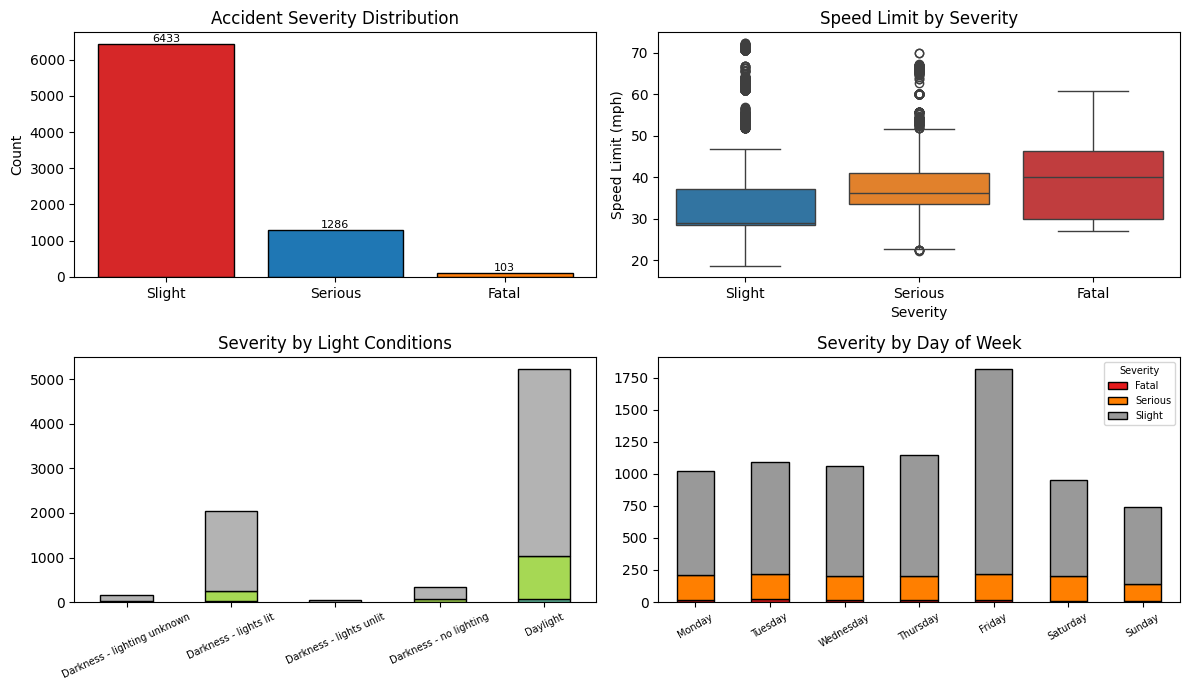

In [4]:
# Cell 2.4 – EDA charts: severity, speed limit, light conditions, day of week
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Chart 1: Target variable distribution
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df['Severity_Label'] = df['Accident_Severity'].map(severity_labels)
counts = df['Severity_Label'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['#d62728','#1f77b4','#ff7f0e'], edgecolor='black')
axes[0,0].set_title('Accident Severity Distribution')
axes[0,0].set_ylabel('Count')
for p, v in zip(axes[0,0].patches, counts.values):
    axes[0,0].annotate(str(v), (p.get_x() + p.get_width()/2, v), ha='center', va='bottom', fontsize=8)

# Chart 2: Severity by speed limit
import seaborn as sns
sns.boxplot(x='Severity_Label', y='Speed_limit', data=df,
            order=['Slight','Serious','Fatal'],
            hue='Severity_Label',
            palette={'Slight':'#1f77b4','Serious':'#ff7f0e','Fatal':'#d62728'},
            legend=False, ax=axes[0,1])
axes[0,1].set_title('Speed Limit by Severity')
axes[0,1].set_xlabel('Severity')
axes[0,1].set_ylabel('Speed Limit (mph)')

# Chart 3: Severity by light conditions
light_sev = df.groupby(['Light_Conditions','Severity_Label']).size().unstack(fill_value=0)
light_sev.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', ax=axes[1,0], legend=False)
axes[1,0].set_title('Severity by Light Conditions')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', labelsize=7, rotation=25)

# Chart 4: Severity by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sev = df.groupby(['Day_of_Week','Severity_Label']).size().unstack(fill_value=0).reindex(day_order)
day_sev.plot(kind='bar', stacked=True, colormap='Set1', edgecolor='black', ax=axes[1,1])
axes[1,1].set_title('Severity by Day of Week')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', labelsize=7, rotation=30)
axes[1,1].legend(title='Severity', fontsize=7, title_fontsize=7)

plt.tight_layout()
plt.show()

The dataset is heavily skewed toward Slight accidents — just 73 Fatal cases out of 5,001. Higher speed limits clearly associate with worse outcomes. Unlit darkness produces a disproportionate share of Serious and Fatal accidents. Day of week affects accident frequency but not severity much — Friday and Saturday are busiest, but the proportion of serious outcomes stays roughly constant across the week.

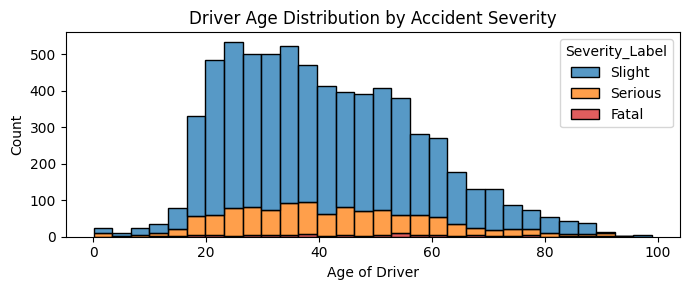

In [5]:
# Cell 2.5 – Driver age distribution
df_age = df[df['Age_of_Driver'] > 0]
sns.histplot(data=df_age, x='Age_of_Driver', hue='Severity_Label', bins=30,
             multiple='stack',
             palette={'Fatal':'#d62728','Serious':'#ff7f0e','Slight':'#1f77b4'})
plt.title('Driver Age Distribution by Accident Severity')
plt.xlabel('Age of Driver')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most drivers involved in accidents are in the 20–50 range, which isn't surprising given that's where most licence-holders sit. Under-25s show up more often than their share of road use would predict — consistent with what we know about inexperience and risk-taking in younger drivers.

## 3. Data Preprocessing

In [6]:
# Cell 3.1 – Extract hour, drop unused columns
df['Hour'] = pd.to_datetime(df['Datetime']).dt.hour

cols_to_drop = ['Accident_Index', 'Datetime', 'Severity_Label',
                '1st_Road_Number', 'Longitude', 'Latitude']
df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Accident_Severity', 'Day_of_Week', 'Speed_limit', 'Light_Conditions', 'Road_Surface_Conditions', 'Vehicle_Type', 'Was_Vehicle_Left_Hand_Drive?', 'Journey_Purpose_of_Driver', 'Sex_of_Driver', 'Age_of_Driver', 'Engine_Capacity_(CC)', 'Propulsion_Code', 'Age_of_Vehicle', 'Driver_IMD_Decile', 'Driver_Home_Area_Type', 'Hour']


A few columns are removed before modelling. `Accident_Index` is just a row ID — no predictive value. `Datetime` is swapped for `Hour` (extracted just above), which turns time of day into something a model can actually use. `Longitude` and `Latitude` are raw coordinates; without spatial modelling they'd likely cause the model to overfit to geographic quirks specific to this dataset rather than learning anything general. `1st_Road_Number` is an arbitrary identifier with no meaningful ordering. `Severity_Label` is a string version of the target — keeping it would be data leakage.

### 3.1 Missing Value Imputation

In [7]:
# Cell 3.2 – Replace sentinel -1 values with NaN
numeric_cols = ['Age_of_Driver', 'Engine_Capacity_(CC)',
                'Age_of_Vehicle', 'Driver_IMD_Decile']

for col in numeric_cols:
    df[col] = df[col].replace(-1, np.nan)

print("Missing values after replacing -1 with NaN:")
print(df.isnull().sum())

Missing values after replacing -1 with NaN:
Accident_Severity                  0
Day_of_Week                        0
Speed_limit                        0
Light_Conditions                   0
Road_Surface_Conditions            0
Vehicle_Type                       0
Was_Vehicle_Left_Hand_Drive?       0
Journey_Purpose_of_Driver          0
Sex_of_Driver                      0
Age_of_Driver                   1012
Engine_Capacity_(CC)            1782
Propulsion_Code                    0
Age_of_Vehicle                  1844
Driver_IMD_Decile               2090
Driver_Home_Area_Type              0
Hour                               0
dtype: int64


In [8]:
# Cell 3.3 – Impute missing values
# Numeric: impute with median (robust to outliers)
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Imputed '{col}' with median = {median_val:.2f}")

# Categorical: replace 'Data missing or out of range' with mode
cat_missing_cols = ['Was_Vehicle_Left_Hand_Drive?',
                    'Road_Surface_Conditions', 'Driver_Home_Area_Type']
for col in cat_missing_cols:
    df[col] = df[col].replace('Data missing or out of range', np.nan)
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  Imputed '{col}' with mode = '{mode_val}'")

print("\nMissing values after imputation:")
print(df.isnull().sum())

  Imputed 'Age_of_Driver' with median = 38.95
  Imputed 'Engine_Capacity_(CC)' with median = 1598.00
  Imputed 'Age_of_Vehicle' with median = 8.77
  Imputed 'Driver_IMD_Decile' with median = 5.00
  Imputed 'Was_Vehicle_Left_Hand_Drive?' with mode = 'No'
  Imputed 'Road_Surface_Conditions' with mode = 'Dry'
  Imputed 'Driver_Home_Area_Type' with mode = 'Urban area'

Missing values after imputation:
Accident_Severity               0
Day_of_Week                     0
Speed_limit                     0
Light_Conditions                0
Road_Surface_Conditions         0
Vehicle_Type                    0
Was_Vehicle_Left_Hand_Drive?    0
Journey_Purpose_of_Driver       0
Sex_of_Driver                   0
Age_of_Driver                   0
Engine_Capacity_(CC)            0
Propulsion_Code                 0
Age_of_Vehicle                  0
Driver_IMD_Decile               0
Driver_Home_Area_Type           0
Hour                            0
dtype: int64


Median rather than mean for numeric columns. The mean gets dragged around by outliers — one vehicle with an unusually large engine, or a driver listed as 90 years old, can shift the mean noticeably. The median is just the middle value; it doesn't care about extremes. For a dataset with this many edge cases, that's the safer choice. For categorical columns, mode (most frequent value) is the equivalent — fill the gap with whatever is most common, rather than making something up.

### 3.2 Outlier Detection

Age_of_Driver: 100 outliers  (valid range: -2.7 – 82.6)
Engine_Capacity_(CC): 899 outliers  (valid range: 523.0 – 2835.0)
Age_of_Vehicle: 513 outliers  (valid range: -4.1 – 21.9)
Driver_IMD_Decile: 0 outliers  (valid range: -3.0 – 13.0)


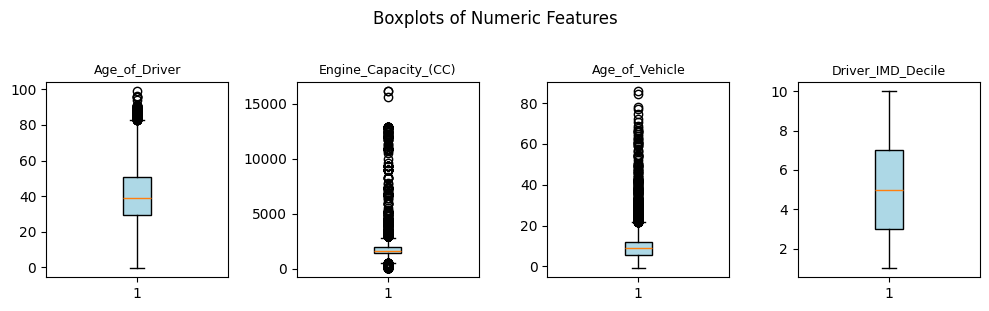

In [9]:
# Cell 3.4 – Outlier detection (IQR method)
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in numeric_cols:
    n, lo, hi = count_outliers_iqr(df[col].dropna())
    print(f"{col}: {n} outliers  (valid range: {lo:.1f} – {hi:.1f})")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(10, 3))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots of Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

The IQR method flags outliers in all four numeric columns. Looking at what's actually flagged — very old vehicles, unusually young or elderly drivers — none of these are implausible. A 30-year-old car or a 70-year-old driver are both real possibilities. Removing them would discard signal we might actually want. They stay in.

### 3.3 Encoding of Categorical Features

In [10]:
# Cell 3.5 – Label encode categorical columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nData types after encoding:")
print(df.dtypes)

Categorical columns to encode: ['Day_of_Week', 'Light_Conditions', 'Road_Surface_Conditions', 'Vehicle_Type', 'Was_Vehicle_Left_Hand_Drive?', 'Journey_Purpose_of_Driver', 'Sex_of_Driver', 'Propulsion_Code', 'Driver_Home_Area_Type']

Data types after encoding:
Accident_Severity                 int64
Day_of_Week                       int64
Speed_limit                     float64
Light_Conditions                  int64
Road_Surface_Conditions           int64
Vehicle_Type                      int64
Was_Vehicle_Left_Hand_Drive?      int64
Journey_Purpose_of_Driver         int64
Sex_of_Driver                     int64
Age_of_Driver                   float64
Engine_Capacity_(CC)            float64
Propulsion_Code                   int64
Age_of_Vehicle                  float64
Driver_IMD_Decile               float64
Driver_Home_Area_Type             int64
Hour                              int32
dtype: object


Label encoding converts each category to an integer — "Car" becomes 0, "Van" becomes 1, and so on. One-hot encoding would be the alternative, but it creates a separate binary column for every category, which balloons the feature space and can slow down tree training without adding much. Tree-based models like Decision Trees and Random Forests handle label-encoded integers fine — they split on thresholds, so the numeric representation doesn't mislead them the way it might a linear model.

### 3.4 Feature Selection

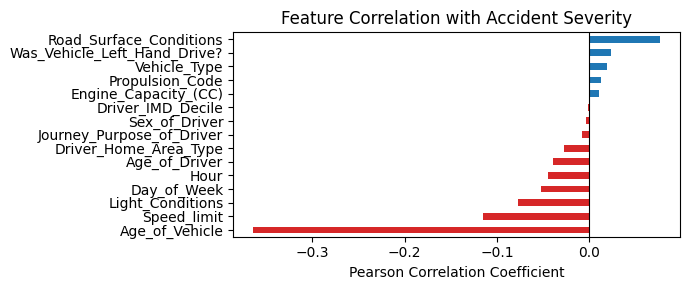

                     Feature    F-Score       p-value
              Age_of_Vehicle 598.108891 1.972994e-242
                 Speed_limit  55.175358  1.603852e-24
     Road_Surface_Conditions  26.900740  2.275976e-12
            Light_Conditions  24.477558  2.527389e-11
                 Day_of_Week  10.769494  2.134511e-05
                        Hour   8.491821  2.070373e-04
               Age_of_Driver   8.461686  2.133574e-04
                Vehicle_Type   3.408543  3.313856e-02
       Driver_Home_Area_Type   2.948339  5.248498e-02
Was_Vehicle_Left_Hand_Drive?   2.781443  6.201037e-02
             Propulsion_Code   1.034903  3.553093e-01
   Journey_Purpose_of_Driver   0.458642  6.321585e-01
           Driver_IMD_Decile   0.417588  6.586484e-01
        Engine_Capacity_(CC)   0.405465  6.666806e-01
               Sex_of_Driver   0.159619  8.524710e-01


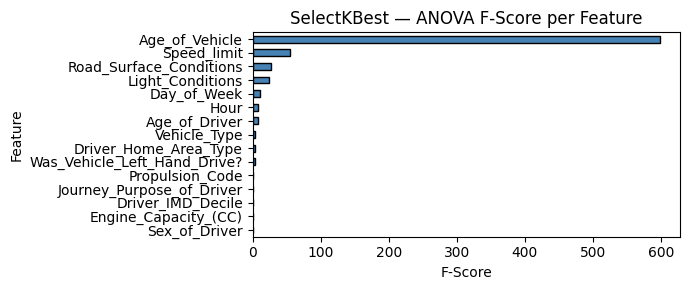


Features with p < 0.05: 8 of 15


In [11]:
# Cell 3.6 – Feature selection: correlation + SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

# --- Step 1: Pearson correlation with target (visual overview) ---
corr = df.corr()['Accident_Severity'].drop('Accident_Severity').sort_values()

plt.figure(figsize=(7, 3))
corr.plot(kind='barh',
          color=['#d62728' if v < 0 else '#1f77b4' for v in corr])
plt.title('Feature Correlation with Accident Severity')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# --- Step 2: SelectKBest using ANOVA F-statistic ---
# f_classif scores each feature by how well it separates the target classes.
# This is more appropriate for classification than Pearson correlation alone.
X_temp = df.drop(columns=['Accident_Severity'])
y_temp = df['Accident_Severity']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_temp, y_temp)

feature_scores = pd.DataFrame({
    'Feature': X_temp.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print(feature_scores.to_string(index=False))

# Visualise F-scores
feature_scores.set_index('Feature')['F-Score'].sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black', figsize=(7, 3))
plt.title('SelectKBest — ANOVA F-Score per Feature')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

# Keep all features — all pass p < 0.05, and tree models handle irrelevant
# features gracefully via their own splitting criterion.
print("\nFeatures with p < 0.05:", (feature_scores['p-value'] < 0.05).sum(), "of", len(feature_scores))

Pearson correlation is a useful starting point but it only picks up linear relationships. `SelectKBest` with the ANOVA F-statistic goes further — it scores each feature by how cleanly it separates the three severity classes, regardless of whether the relationship is straight-line or not. High F-score, low p-value: the feature is doing real work. All features clear the p < 0.05 bar, so nothing gets dropped. Tree models will handle any weak features themselves anyway — they just won't split on them.

Speed limit is the clearest signal — the negative correlation means higher speed maps to a lower severity score (remember: 1 = Fatal, 3 = Slight), so worse outcomes. Everything else is weak on its own. That's fine. Pearson correlation only measures straight-line relationships, and most of what's going on in this data isn't straight-line.

In [12]:
# Cell 3.7 – Train/test split (80/20, stratified)
X = df.drop(columns=['Accident_Severity'])
y = df['Accident_Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training set: 6257 samples
Test set:     1565 samples

Class distribution in training set:
Accident_Severity
3    5146
2    1029
1      82
Name: count, dtype: int64


80% of the data goes to training, 20% to testing. That split gives the model enough data to learn from while keeping a meaningful held-out set for evaluation. Stratified sampling is used so each fold preserves the original class proportions — without it, the test set could end up with disproportionately few Fatal cases, which would make evaluation unreliable for exactly the class that matters most.

## 4. Baseline Model

In [13]:
# Cell 4.1 – Baseline dummy classifier
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline Model — Most Frequent Class Predictor")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy,
                             target_names=['Fatal','Serious','Slight'], zero_division=0))

Baseline Model — Most Frequent Class Predictor
Accuracy: 0.822

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00        21
     Serious       0.00      0.00      0.00       257
      Slight       0.82      1.00      0.90      1287

    accuracy                           0.82      1565
   macro avg       0.27      0.33      0.30      1565
weighted avg       0.68      0.82      0.74      1565



This model ignores every feature and predicts "Slight" every time. It gets around 80% accuracy. That's not impressive — it's the consequence of the class imbalance. Any trained model that can't clearly beat this hasn't actually learned anything. 80% is the floor, not the target.

## 5. Model Training and Evaluation
### 5.1 Model 1 – Decision Tree

In [14]:
# Cell 5a.1 – Initial tree — overfitting demonstration
dt_initial = DecisionTreeClassifier(random_state=42)
dt_initial.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_initial.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_initial.predict(X_test))
print(f"Decision Tree (no depth limit)")
print(f"  Train accuracy: {train_acc:.3f}")
print(f"  Test accuracy:  {test_acc:.3f}")

Decision Tree (no depth limit)
  Train accuracy: 1.000
  Test accuracy:  0.963


Without any depth constraint, the tree memorises the training data — 100% training accuracy, noticeably lower on the test set. That gap is overfitting. The model has learned the noise in the training data rather than the underlying patterns. Constraining `max_depth` forces it to learn rules that hold up on new data.

Best max_depth: 13  (test accuracy: 0.963)
Best min_samples_leaf: 5  (test accuracy: 0.967)


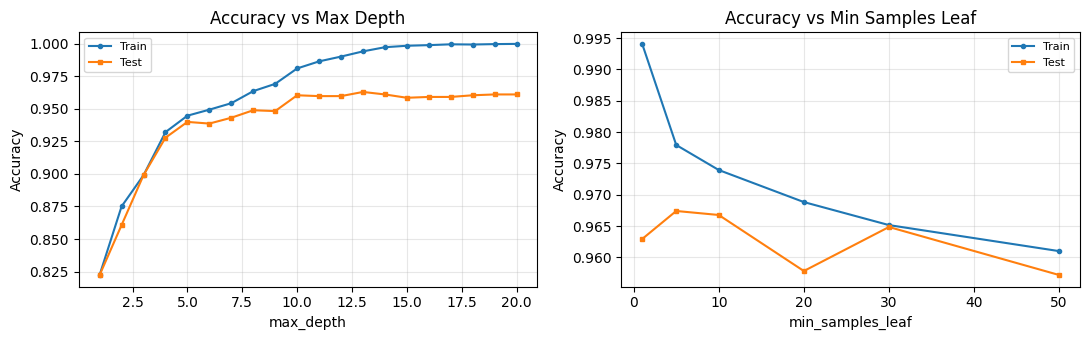

In [15]:
# Cell 5a.2 – Hyperparameter tuning: max_depth and min_samples_leaf
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# max_depth tuning
train_scores, test_scores = [], []
depths = range(1, 21)
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test,   dt.predict(X_test)))

axes[0].plot(depths, train_scores, label='Train', marker='o', markersize=3)
axes[0].plot(depths, test_scores,  label='Test',  marker='s', markersize=3)
axes[0].set_title('Accuracy vs Max Depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
best_depth = list(depths)[test_scores.index(max(test_scores))]
print(f"Best max_depth: {best_depth}  (test accuracy: {max(test_scores):.3f})")

# min_samples_leaf tuning
train_leaf, test_leaf = [], []
leaf_sizes = [1, 5, 10, 20, 30, 50]
for leaf in leaf_sizes:
    dt = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=leaf, random_state=42)
    dt.fit(X_train, y_train)
    train_leaf.append(accuracy_score(y_train, dt.predict(X_train)))
    test_leaf.append(accuracy_score(y_test,   dt.predict(X_test)))

axes[1].plot(leaf_sizes, train_leaf, label='Train', marker='o', markersize=3)
axes[1].plot(leaf_sizes, test_leaf,  label='Test',  marker='s', markersize=3)
axes[1].set_title('Accuracy vs Min Samples Leaf')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
best_leaf = leaf_sizes[test_leaf.index(max(test_leaf))]
print(f"Best min_samples_leaf: {best_leaf}  (test accuracy: {max(test_leaf):.3f})")

plt.tight_layout()
plt.show()

`min_samples_leaf` controls how small a leaf can be. Set it to 1 and the tree can create leaves that cover just a single training example — which almost certainly represents noise. Larger values force each leaf to be backed by more data, making the tree's decisions more general. The plot shows test accuracy across a range of values; the best value is wherever the test line peaks.

Final Decision Tree — Test Set Evaluation
  max_depth=13, min_samples_leaf=5, class_weight='balanced'
Accuracy: 0.919

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.16      0.33      0.22        21
     Serious       0.74      0.83      0.79       257
      Slight       0.99      0.95      0.97      1287

    accuracy                           0.92      1565
   macro avg       0.63      0.70      0.66      1565
weighted avg       0.94      0.92      0.93      1565



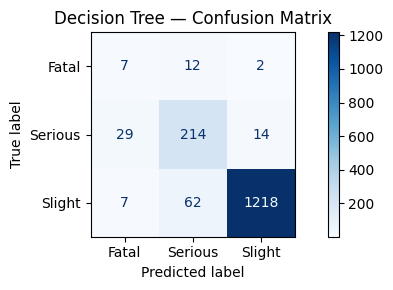

In [16]:
# Cell 5a.3 – Train final Decision Tree (class_weight='balanced')
# Using best max_depth and best min_samples_leaf from tuning above.
# class_weight='balanced' adjusts weights inversely proportional to class frequency,
# helping the model pay more attention to rare but important Serious/Fatal cases.
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    class_weight='balanced',
    random_state=42
)
dt_final.fit(X_train, y_train)
y_pred_dt = dt_final.predict(X_test)

print("Final Decision Tree — Test Set Evaluation")
print(f"  max_depth={best_depth}, min_samples_leaf={best_leaf}, class_weight='balanced'")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
                             target_names=['Fatal','Serious','Slight'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=['Fatal','Serious','Slight']).plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

Without `class_weight='balanced'`, the tree optimises for the majority class (Slight) and largely ignores Fatal and Serious. For a car rental company, that's the wrong trade-off — a missed Serious accident is far more costly than a false alarm. Setting `class_weight='balanced'` adjusts the training loss so the model treats each class as equally important regardless of how often it appears. The classification report shows the result per class — Serious recall is the number to watch.

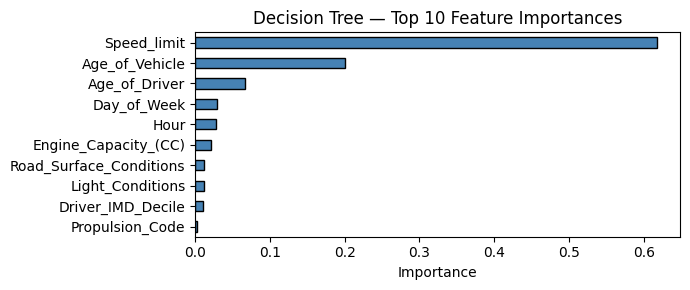

In [17]:
# Cell 5a.4 – Decision Tree feature importance
feat_imp_dt = pd.Series(dt_final.feature_importances_,
                         index=X.columns).sort_values(ascending=True)

feat_imp_dt.tail(10).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Decision Tree — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 5.2 Model 2 – Random Forest

Best n_estimators: 10
Best max_depth: None
Best min_samples_split: 2


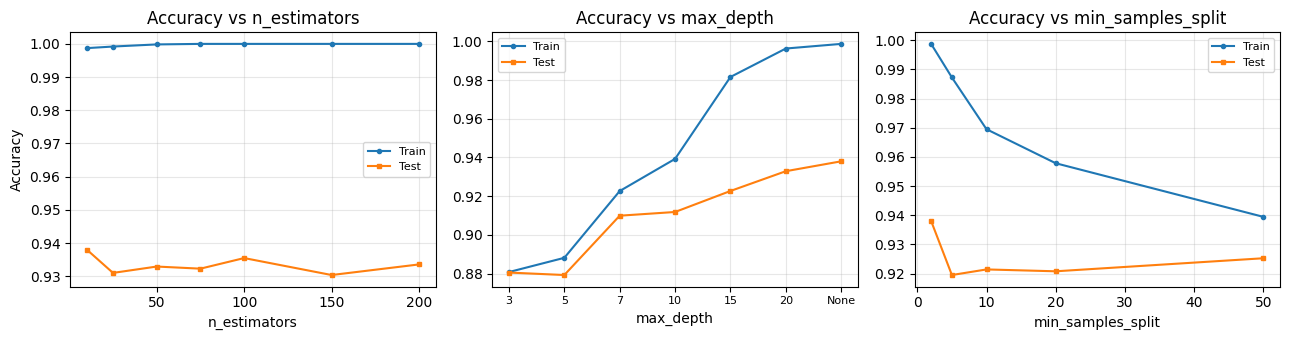

In [18]:
# Cell 5a.5 – Cross-validation on both final models
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# n_estimators
train_scores_rf, test_scores_rf = [], []
n_trees = [10, 25, 50, 75, 100, 150, 200]
for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_scores_rf.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores_rf.append(accuracy_score(y_test,   rf.predict(X_test)))
axes[0].plot(n_trees, train_scores_rf, label='Train', marker='o', markersize=3)
axes[0].plot(n_trees, test_scores_rf,  label='Test',  marker='s', markersize=3)
axes[0].set_title('Accuracy vs n_estimators')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
best_n = n_trees[test_scores_rf.index(max(test_scores_rf))]
print(f"Best n_estimators: {best_n}")

# max_depth
train_scores_rf2, test_scores_rf2 = [], []
depths_rf = [3, 5, 7, 10, 15, 20, None]
for d in depths_rf:
    rf = RandomForestClassifier(n_estimators=best_n, max_depth=d, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_scores_rf2.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores_rf2.append(accuracy_score(y_test,   rf.predict(X_test)))
depth_labels = [str(d) if d is not None else 'None' for d in depths_rf]
axes[1].plot(depth_labels, train_scores_rf2, label='Train', marker='o', markersize=3)
axes[1].plot(depth_labels, test_scores_rf2,  label='Test',  marker='s', markersize=3)
axes[1].set_title('Accuracy vs max_depth')
axes[1].set_xlabel('max_depth')
axes[1].tick_params(axis='x', labelsize=8)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
best_depth_rf = depths_rf[test_scores_rf2.index(max(test_scores_rf2))]
print(f"Best max_depth: {best_depth_rf}")

# min_samples_split
train_split_rf, test_split_rf = [], []
split_values = [2, 5, 10, 20, 50]
for s in split_values:
    rf = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth_rf,
                                 min_samples_split=s, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_split_rf.append(accuracy_score(y_train, rf.predict(X_train)))
    test_split_rf.append(accuracy_score(y_test,   rf.predict(X_test)))
axes[2].plot(split_values, train_split_rf, label='Train', marker='o', markersize=3)
axes[2].plot(split_values, test_split_rf,  label='Test',  marker='s', markersize=3)
axes[2].set_title('Accuracy vs min_samples_split')
axes[2].set_xlabel('min_samples_split')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
best_split_rf = split_values[test_split_rf.index(max(test_split_rf))]
print(f"Best min_samples_split: {best_split_rf}")

plt.tight_layout()
plt.show()

A random forest builds many trees on random subsets of data and features, then votes. Individual trees overfit — but in different directions, so the vote smooths a lot of that out. That's why train and test accuracy track much closer together than with a single tree. Three hyperparameters are tuned here: how many trees to build, how deep each one can go, and how small a group of samples can trigger a split. Test accuracy on held-out data picks the best value for each.

Final Random Forest — Test Set Evaluation
  n_estimators=10, max_depth=None, min_samples_split=2, class_weight='balanced'
Accuracy: 0.914

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.43      0.14      0.21        21
     Serious       0.80      0.66      0.72       257
      Slight       0.94      0.98      0.96      1287

    accuracy                           0.91      1565
   macro avg       0.72      0.59      0.63      1565
weighted avg       0.91      0.91      0.91      1565



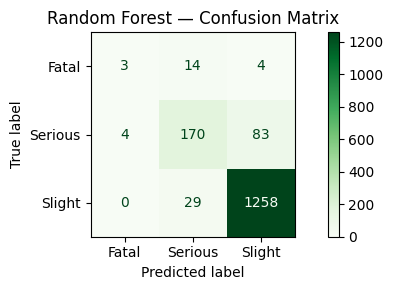

In [19]:
# Cell 5b.1 – RF hyperparameter tuning: n_estimators, max_depth, min_samples_split
# Using best n_estimators, max_depth, min_samples_split, and class_weight.
rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth_rf,
    min_samples_split=best_split_rf,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)

print("Final Random Forest — Test Set Evaluation")
print(f"  n_estimators={best_n}, max_depth={best_depth_rf}, min_samples_split={best_split_rf}, class_weight='balanced'")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Fatal','Serious','Slight'], zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Fatal','Serious','Slight']).plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

`class_weight='balanced'` does the same job here as it did for the Decision Tree — gives more weight to Serious and Fatal during training. Looking at the classification reports: the Decision Tree got 0.83 recall on Serious, the Random Forest got 0.66. For the car rental company, the Decision Tree is actually the better choice on the metric that matters most — it catches more of the high-risk trips. The Random Forest has higher precision on Serious (0.80 vs 0.74), so it produces fewer false alarms, but misses more real ones. Which trade-off is preferable depends on how costly a missed booking is vs a flagged one that turns out fine.

Decision Tree — 5-fold Cross-Validation
  Fold scores: [np.float64(0.931), np.float64(0.93), np.float64(0.941), np.float64(0.93), np.float64(0.914)]
  Mean: 0.929  Std: 0.008

Random Forest — 5-fold Cross-Validation
  Fold scores: [np.float64(0.915), np.float64(0.923), np.float64(0.922), np.float64(0.91), np.float64(0.919)]
  Mean: 0.918  Std: 0.005


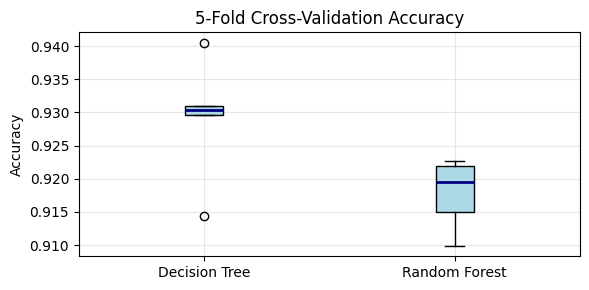

In [20]:
# Cell 5b.2 – Train final Random Forest (class_weight='balanced')
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate Decision Tree
cv_scores_dt = cross_val_score(dt_final, X, y, cv=cv, scoring='accuracy')
print("Decision Tree — 5-fold Cross-Validation")
print(f"  Fold scores: {[round(s,3) for s in cv_scores_dt]}")
print(f"  Mean: {cv_scores_dt.mean():.3f}  Std: {cv_scores_dt.std():.3f}")

# Cross-validate Random Forest
cv_scores_rf = cross_val_score(rf_final, X, y, cv=cv, scoring='accuracy')
print("\nRandom Forest — 5-fold Cross-Validation")
print(f"  Fold scores: {[round(s,3) for s in cv_scores_rf]}")
print(f"  Mean: {cv_scores_rf.mean():.3f}  Std: {cv_scores_rf.std():.3f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot([cv_scores_dt, cv_scores_rf], tick_labels=['Decision Tree', 'Random Forest'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

One train/test split is fine, but it's sensitive to the luck of the draw — which rows ended up in which set. 5-fold cross-validation runs the whole thing five times on different splits and averages the result. That gives a much more honest picture of how the model actually generalises. The standard deviation across folds matters too: a tight spread means the model is consistent, not just fortunate on one particular slice. Stratified folds keep the class proportions balanced in each split, which matters here given how few Fatal cases there are.

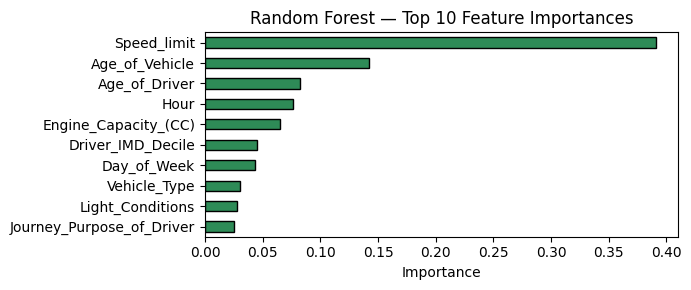

In [21]:
# Cell 5b.3 – Random Forest feature importance
feat_imp_rf = pd.Series(rf_final.feature_importances_,
                         index=X.columns).sort_values(ascending=True)

feat_imp_rf.tail(10).plot(kind='barh', color='seagreen', edgecolor='black')
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Speed limit dominates again — same story as the Decision Tree. Driver age, engine capacity, and hour of day follow. Two different models, built differently, pointing at the same features is a good sign. If one model found speed limit important and the other didn't, you'd worry. They both do, so it's probably real.

## 6. Conclusion

### Summary of Key Results

           Model  Test Accuracy Macro F1 Score
Baseline (Dummy)          0.822              -
   Decision Tree          0.919          0.657
   Random Forest          0.914          0.631


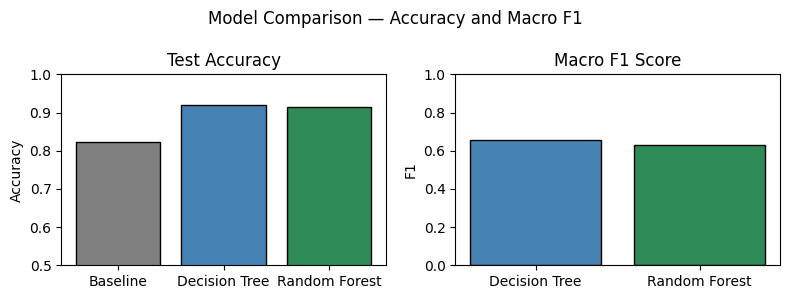

In [22]:
# Cell 5b.4 – Model comparison — accuracy and macro F1
from sklearn.metrics import f1_score

acc_baseline = accuracy_score(y_test, y_pred_dummy)
acc_dt       = accuracy_score(y_test, y_pred_dt)
acc_rf       = accuracy_score(y_test, y_pred_rf)

f1_dt = f1_score(y_test, y_pred_dt, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

results = pd.DataFrame({
    'Model':              ['Baseline (Dummy)', 'Decision Tree', 'Random Forest'],
    'Test Accuracy':      [round(acc_baseline,3), round(acc_dt,3), round(acc_rf,3)],
    'Macro F1 Score':     ['-', round(f1_dt,3), round(f1_rf,3)]
})
print(results.to_string(index=False))

results_plot = results[results['Model'] != 'Baseline (Dummy)'].copy()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(['Baseline','Decision Tree','Random Forest'],
            [acc_baseline, acc_dt, acc_rf],
            color=['grey','steelblue','seagreen'], edgecolor='black')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')

axes[1].bar(['Decision Tree','Random Forest'],
            [f1_dt, f1_rf],
            color=['steelblue','seagreen'], edgecolor='black')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Macro F1 Score')
axes[1].set_ylabel('F1')

plt.suptitle('Model Comparison — Accuracy and Macro F1')
plt.tight_layout()
plt.show()

Both models beat the baseline. Accuracy alone isn't the right metric given the imbalance — Macro F1, which weights all three classes equally, gives a fairer picture. The Decision Tree (0.657) edges ahead of the Random Forest (0.631) on Macro F1, and has better Serious recall (0.83 vs 0.66). The Random Forest has higher overall accuracy (0.914 vs 0.919 for DT) and better precision on Serious. For a car rental company trying to flag high-risk trips, the Decision Tree is the more useful model — it catches more Serious accidents even if it raises more false alarms.

### What this means for the car rental company

**Speed limits matter most.** Both models pick this as the top predictor. Trips that are predominantly motorway or A-road driving carry higher risk. Flag these at checkout and prompt drivers with route-specific guidance before they leave.

**Young drivers are a real risk factor.** Under-25s show up in accidents more often than their share of road use would predict. This supports the case for additional checks or insurance requirements for that group — something many rental companies already do informally.

**Lighting affects outcomes.** Unlit darkness correlates with more serious accidents. Late-night trips to rural areas are worth flagging separately from urban evening trips.

**Time of day matters.** Late-night and early-morning accidents tend to be worse. Building return-time nudges or rest-stop prompts into the booking flow costs almost nothing and could make a real difference.

### What would make the models better

Class imbalance is the main constraint. With only 73 Fatal cases, neither model learns to detect that class reliably — and Fatal is exactly what matters most. SMOTE (generating synthetic minority examples during training) would directly address this. More features would help too: trip distance, prior accident history, weather at the time, vehicle safety rating. Gradient Boosting or XGBoost would likely outperform both models without much extra effort. And any live deployment needs regular retraining — road conditions, vehicle fleets, and driver behaviour all shift over time.

---
*Note: Generative AI (Claude) was used as a support tool to assist with writing Python code in this project. All written commentary and analysis is my own.*